In [2]:
# =============================================================================
# NOTEBOOK 8
# Spatial Persistence and Variability
#
# Purpose
# -------
# Analyze the long-term persistence and variability of rainfall
# over the entire radar domain.
#
# Products used
# -------------
# mean_grid.npy
# std_grid.npy
# rain_probability.npy
#
# Generated figures
# -----------------
# figure18_spatial_variability.png
# figure19_variability_ratio.png
# figure20_probability_histogram.png
# =============================================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

OUTPUT = Path("datasets/radar_statistics")
FIGURES = Path("figures")

FIGURES.mkdir(exist_ok=True)

In [3]:
mean_grid = np.load(
    OUTPUT / "mean_grid.npy"
)

std_grid = np.load(
    OUTPUT / "std_grid.npy"
)

rain_probability = np.load(
    OUTPUT / "rain_probability.npy"
)

In [4]:
cv = std_grid / (mean_grid + 1e-6)

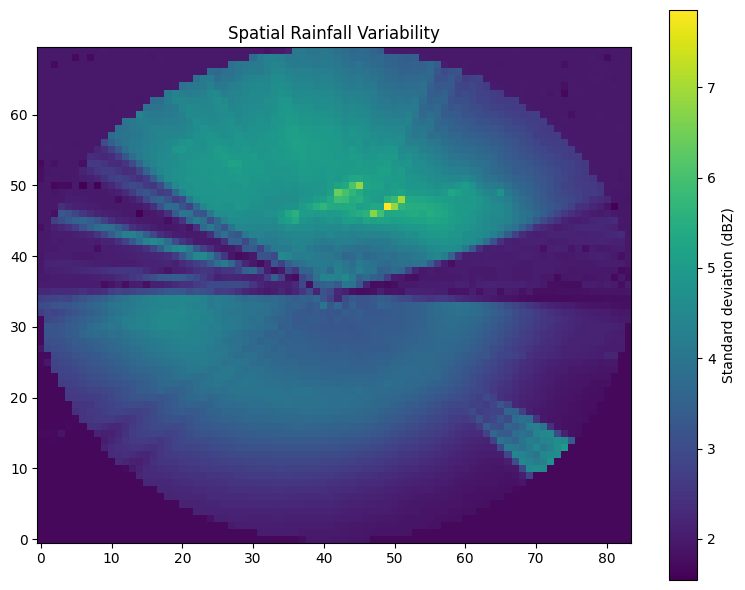

In [5]:
plt.figure(figsize=(8,6))

plt.imshow(
    std_grid,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="Standard deviation (dBZ)")

plt.title("Spatial Rainfall Variability")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure18_spatial_variability.png",
    dpi=300
)

plt.show()

In [6]:
print("="*60)

print("Spatial Persistence Summary")

print("="*60)

print(f"Mean rain probability : {rain_probability.mean():.4f}")
print(f"Median probability    : {np.median(rain_probability):.4f}")
print(f"Maximum probability   : {rain_probability.max():.4f}")

print()

print(f"Mean variability      : {std_grid.mean():.3f}")
print(f"Maximum variability   : {std_grid.max():.3f}")

print()

print(f"Mean CV               : {cv.mean():.3f}")
print(f"Maximum CV            : {cv.max():.3f}")

Spatial Persistence Summary
Mean rain probability : 0.0125
Median probability    : 0.0098
Maximum probability   : 0.0754

Mean variability      : 2.996
Maximum variability   : 7.856

Mean CV               : 13.402
Maximum CV            : 23.696


In [7]:
idx = np.unravel_index(
    np.argmax(rain_probability),
    rain_probability.shape
)

print("Most persistent rainfall pixel")
print("------------------------------")
print(f"Grid position : {idx}")
print(f"Probability   : {rain_probability[idx]:.4f}")
print(f"Mean rainfall : {mean_grid[idx]:.2f}")
print(f"Std rainfall  : {std_grid[idx]:.2f}")

Most persistent rainfall pixel
------------------------------
Grid position : (np.int64(47), np.int64(49))
Probability   : 0.0754
Mean rainfall : 2.14
Std rainfall  : 7.86


Most variable rainfall pixel
----------------------------
Grid position : (np.int64(47), np.int64(49))
Std           : 7.86
Mean          : 2.14
Probability   : 0.0754


In [9]:
idx = np.unravel_index(
    np.argmax(std_grid),
    std_grid.shape
)

print("Most variable rainfall pixel")
print("----------------------------")
print(f"Grid position : {idx}")
print(f"Std           : {std_grid[idx]:.2f}")
print(f"Mean          : {mean_grid[idx]:.2f}")
print(f"Probability   : {rain_probability[idx]:.4f}")

Most variable rainfall pixel
----------------------------
Grid position : (np.int64(47), np.int64(49))
Std           : 7.86
Mean          : 2.14
Probability   : 0.0754


In [10]:
corr = np.corrcoef(
    rain_probability.flatten(),
    std_grid.flatten()
)[0,1]

print(f"Correlation (Probability x Variability): {corr:.3f}")

Correlation (Probability x Variability): 0.979


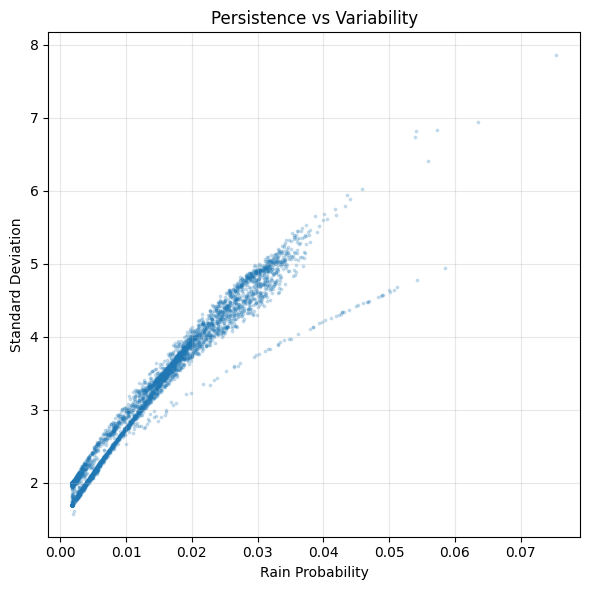

In [11]:
sample = np.random.choice(
    rain_probability.size,
    5000,
    replace=False
)

plt.figure(figsize=(6,6))

plt.scatter(
    rain_probability.flatten()[sample],
    std_grid.flatten()[sample],
    s=3,
    alpha=0.2
)

plt.xlabel("Rain Probability")

plt.ylabel("Standard Deviation")

plt.title("Persistence vs Variability")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure21_probability_vs_variability.png",
    dpi=300
)

plt.show()